<a href="https://colab.research.google.com/github/mducdaf2/tensorflow/blob/main/3_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3 - Convolutional Neural Networks with Sequential and Functional API

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oxcdcd/cifar10")

print("Path to dataset files:", path)

100%|██████████| 175M/175M [00:01<00:00, 155MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/oxcdcd/cifar10/versions/1


In [3]:
import os

os.listdir(path)

['readme.txt', 'cifar10']

In [4]:
os.listdir(path + "/cifar10")

['train', 'test', 'labels.txt']

In [5]:
import os
import numpy as np
from PIL import Image

# Đường dẫn gốc (thay path cho đúng với máy bạn)
base_path = path + "/cifar10"

# Đọc thứ tự class từ labels.txt để đảm bảo đúng mapping (0=airplane, 1=automobile, ...)
with open(os.path.join(base_path, "labels.txt"), "r") as f:
    class_names = [line.strip() for line in f.readlines()]

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
print(class_to_idx)


def load_dataset(split_dir):
    """
    split_dir: 'train' hoặc 'test'
    Trả về images (N, 32, 32, 3) uint8 và labels (N,) int
    """
    images = []
    labels = []

    split_path = os.path.join(base_path, split_dir)

    for class_name in class_names:
        class_folder = os.path.join(split_path, class_name)
        label_idx = class_to_idx[class_name]

        for fname in os.listdir(class_folder):
            fpath = os.path.join(class_folder, fname)
            img = Image.open(fpath).convert("RGB")
            img_arr = np.array(img, dtype=np.uint8)
            images.append(img_arr)
            labels.append(label_idx)

    images = np.array(images, dtype=np.uint8)
    labels = np.array(labels, dtype=np.int64)

    return images, labels


# Load train và test
x_train, y_train = load_dataset("train")
x_test, y_test = load_dataset("test")

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


In [6]:
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

In [7]:
x_train[0].shape

(32, 32, 3)

ImportError: cannot import name 'image' from 'tensorflow.keras.visualization' (/usr/local/lib/python3.12/dist-packages/keras/_tf_keras/keras/visualization/__init__.py)

In [59]:
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(filters=32, kernel_size=3, padding="valid"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPool2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(filters=64, kernel_size=3, padding="valid"),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(filters=128, kernel_size=3, padding="valid"),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    # layers.Flatten(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

print(model.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,210 (418.79 KB)

 Trainable params: 106,762 (417.04 KB)

 Non-trainable params: 448 (1.75 KB)

None


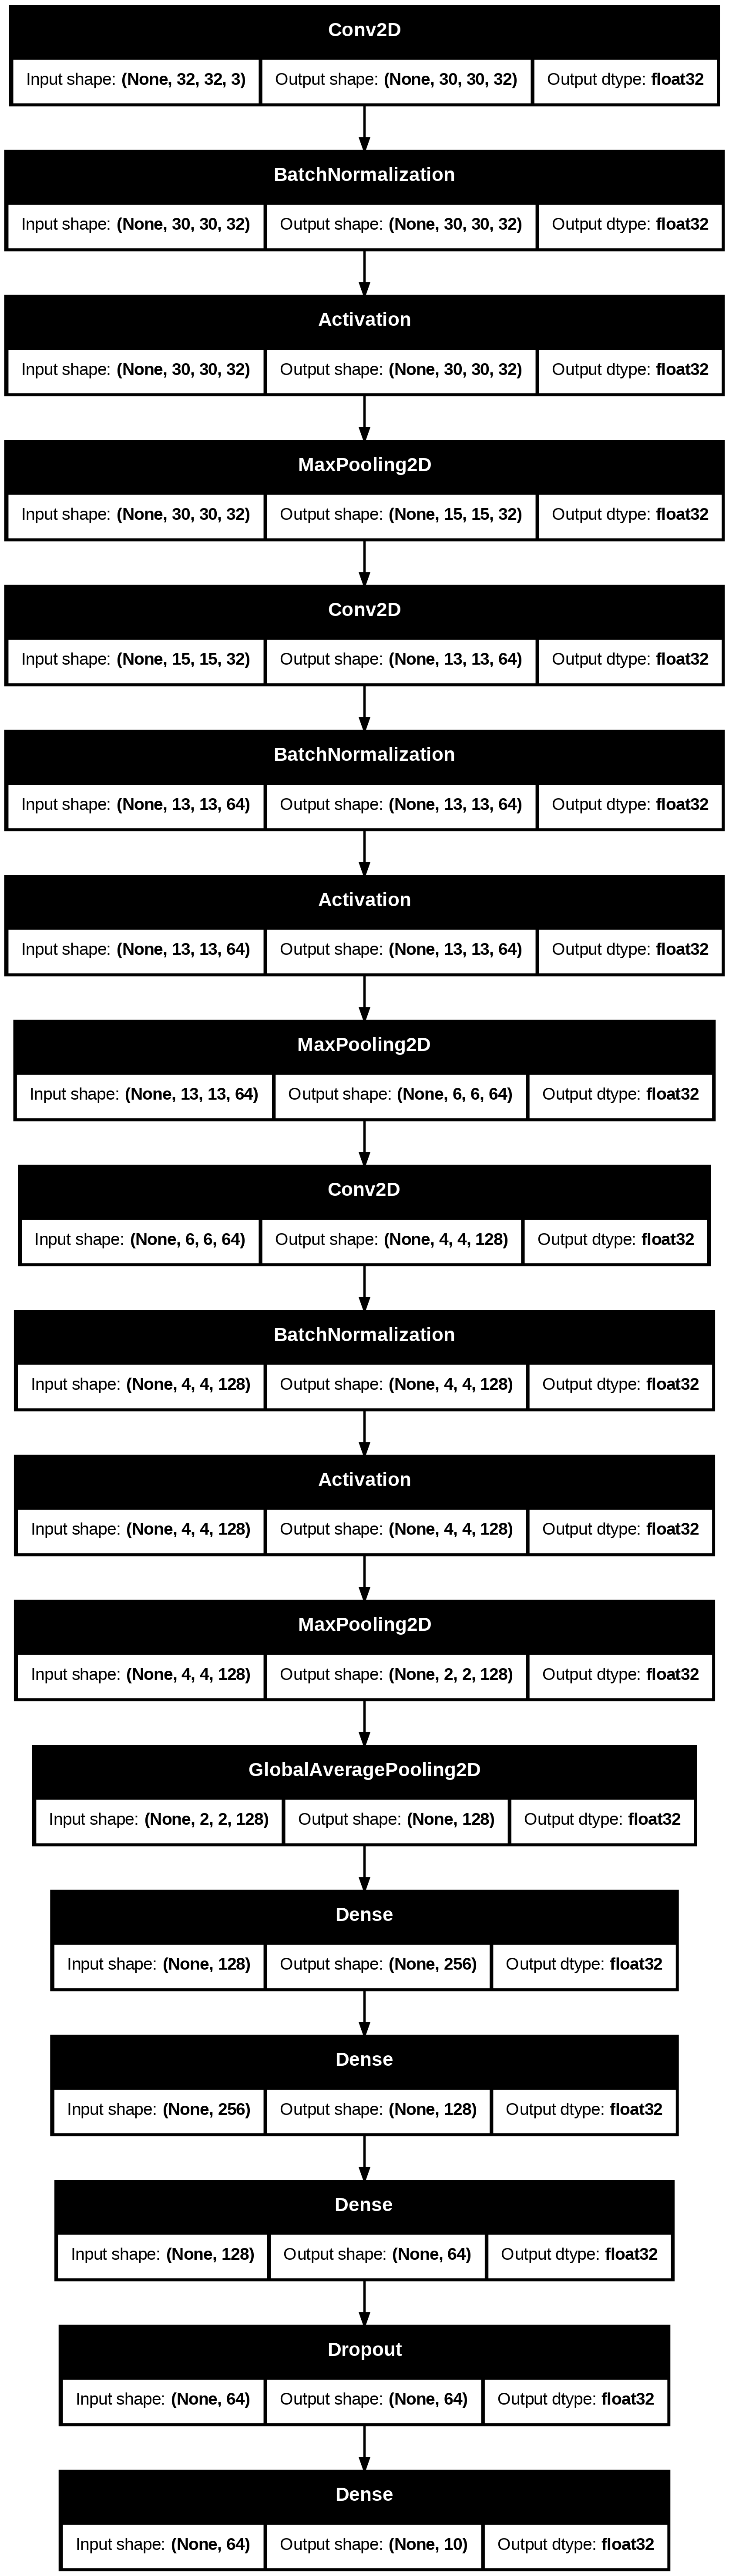

In [45]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_dtype=True)

In [60]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

In [61]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=2, validation_data=(x_test, y_test))

Epoch 1/20
1563/1563 - 18s - 12ms/step - accuracy: 0.4795 - loss: 1.4342 - val_accuracy: 0.2271 - val_loss: 3.0507
Epoch 2/20
1563/1563 - 7s - 5ms/step - accuracy: 0.5992 - loss: 1.1298 - val_accuracy: 0.5578 - val_loss: 1.2526
Epoch 3/20
1563/1563 - 8s - 5ms/step - accuracy: 0.6458 - loss: 1.0061 - val_accuracy: 0.3915 - val_loss: 1.9531
Epoch 4/20
1563/1563 - 8s - 5ms/step - accuracy: 0.6759 - loss: 0.9282 - val_accuracy: 0.5504 - val_loss: 1.3317
Epoch 5/20
1563/1563 - 7s - 5ms/step - accuracy: 0.7027 - loss: 0.8599 - val_accuracy: 0.6519 - val_loss: 1.0309
Epoch 6/20
1563/1563 - 8s - 5ms/step - accuracy: 0.7209 - loss: 0.8068 - val_accuracy: 0.6732 - val_loss: 0.9255
Epoch 7/20
1563/1563 - 7s - 5ms/step - accuracy: 0.7363 - loss: 0.7626 - val_accuracy: 0.7333 - val_loss: 0.7691
Epoch 8/20
1563/1563 - 7s - 5ms/step - accuracy: 0.7514 - loss: 0.7240 - val_accuracy: 0.6346 - val_loss: 1.1072
Epoch 9/20
1563/1563 - 8s - 5ms/step - accuracy: 0.7625 - loss: 0.6881 - val_accuracy: 0.6098 

In [62]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


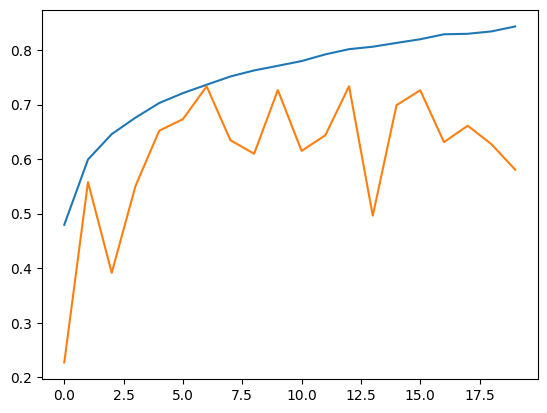

In [63]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

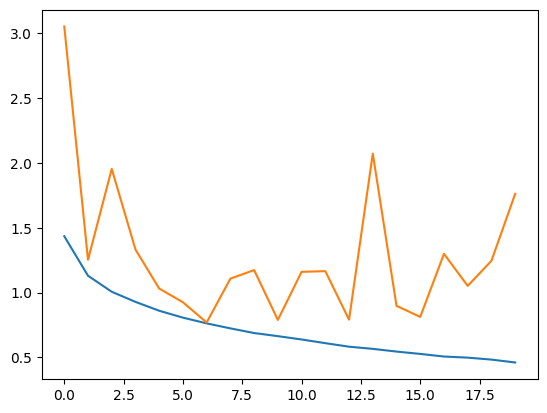

In [64]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [66]:
!pip install -U -q tf-models-official

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.2 MB/s eta 0:00:00
